### **Student Name:** Amey Khodke

 **Problem Statement:** Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

 
 **Dataset used:** Customer Personality Analysis Dataset <br>
 **Dataset Link:** https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis <br>

**Why this Dataset ?** <br>
The dataset provided in the portal was based on country dataset rather than customer data, which was not correct for solving the customer intelligence problem statement. Thats why we can not perfrom Customer Operations on it thats why, I choose the Customer Personality Analysis dataset,  which is better aligned with customer behavior analysis.

IMPORTING LIBRARIES

In [2]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

DATASET UNDERSTANDING

In [3]:
# Dataset Loading and Understanding
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Displaying the first few rows of the dataset
display(df.head())

# checking the null values in the dataset
print('Checking Null Values in the dataset')
display(df.isnull().sum())

# Checking the no. of columns and rows in the dataset
print('The shape of the dataset is: ', df.shape)

# Describing the dataset to understand the summary
print('Summary of the Dataset:')
display(df.describe())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Checking Null Values in the dataset


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

The shape of the dataset is:  (2240, 29)
Summary of the Dataset:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


DATA CLEANING (HANDLING MISSING VALUES AND DUPLICATES)

In [4]:
# Data Cleaning

# Handle missing values in the income column with median
df['Income'].fillna(df['Income'].median(), inplace=True)

C:\Users\ameyk\AppData\Local\Temp\ipykernel_5804\1551463285.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


FEATURE ENGINEERING

In [5]:
# converting Age column
df['Age'] = 2024 - df['Year_Birth']

# converting Dt_Customer column to datetime format
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# Making the new feature 'Total_spendings' by adding the columns 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', and 'MntSweetProducts'
df['Total_spendings'] = df['MntWines'] + df['MntFruits'] + df['MntFishProducts'] + df['MntMeatProducts'] + df['MntSweetProducts']

# Making the new feature 'Total_purchases' by adding the columns 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', and 'NumStorePurchases'
df['Total_purchases'] = df['NumDealsPurchases'] + df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

In [6]:
print(df.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_spendings', 'Total_purchases'],
      dtype='object')


EXPLORATORY DATA ANALYSIS (EDA)

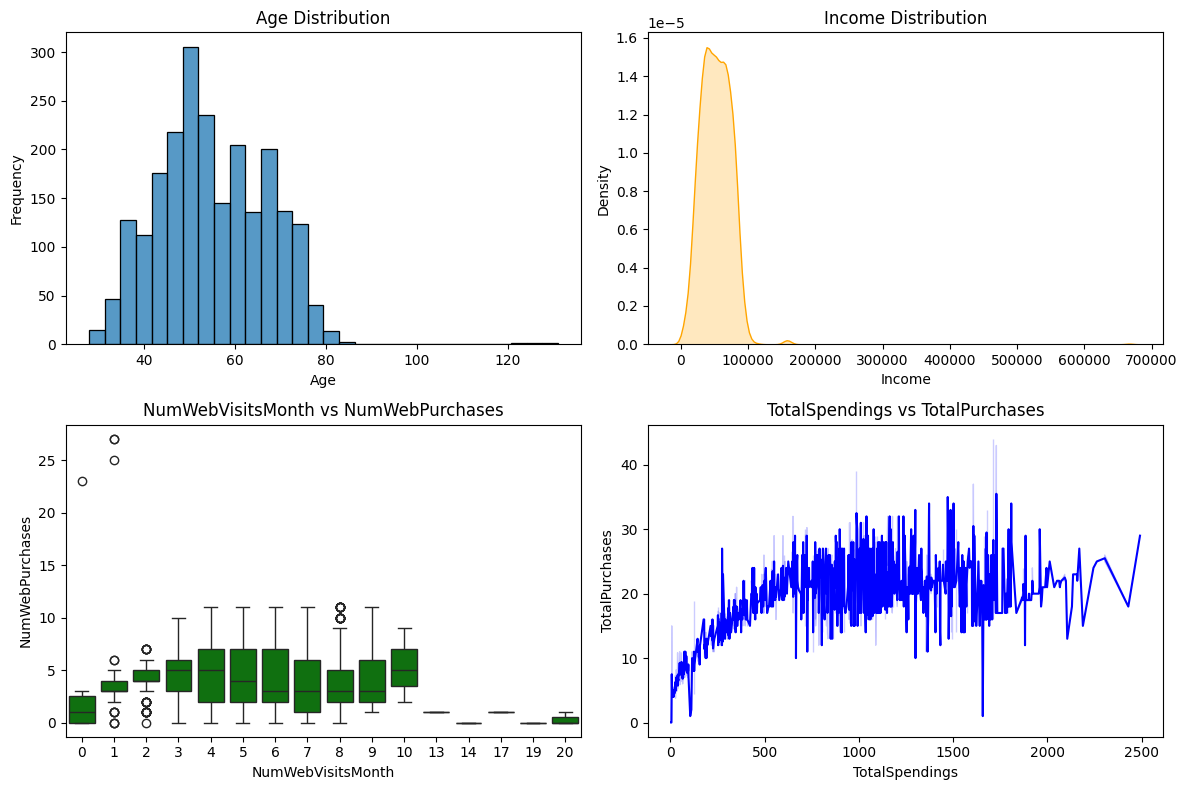

In [7]:
# Univariate Analysis
fig, ax = plt.subplots(2,2,figsize=(12,8))
# Plotting Age Distribution
sns.histplot(df['Age'], bins=30, ax=ax[0,0])
ax[0,0].set_title('Age Distribution')
ax[0,0].set_xlabel('Age')
ax[0,0].set_ylabel('Frequency')

# Plotting Income Distribution
sns.kdeplot(df['Income'], ax=ax[0,1], color='orange', fill=True)
ax[0,1].set_title('Income Distribution')
ax[0,1].set_xlabel('Income')
ax[0,1].set_ylabel('Density')

# Bivariate Analysis

# Plotting NumWebVisitsMonth vs NumWebPurchases
sns.boxplot(x='NumWebVisitsMonth', y='NumWebPurchases', data=df, ax=ax[1,0], color='green')
ax[1,0].set_title('NumWebVisitsMonth vs NumWebPurchases')
ax[1,0].set_xlabel('NumWebVisitsMonth')
ax[1,0].set_ylabel('NumWebPurchases')

# Plotting TotalSpendings vs TotalPurchases
sns.lineplot(x='Total_spendings', y='Total_purchases', data=df, ax=ax[1,1], color='blue')
ax[1,1].set_title('TotalSpendings vs TotalPurchases')
ax[1,1].set_xlabel('TotalSpendings')
ax[1,1].set_ylabel('TotalPurchases')

plt.tight_layout()
plt.show()

SPLITTING THE DATA X AND Y

In [8]:
# splitting the dataset
X = df.drop(['ID', 'Year_Birth', 'Dt_Customer','Response', 'Z_CostContact', 'Z_Revenue'], axis=1)
y = df['Response']

TRAIN TEST SPLIT

In [9]:
# splitting the dataset into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

PREPROCESSING

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Education', 'Marital_Status']:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.fit_transform(X_test[col])

TRAINING THE MODEL (XGBOOST)

In [11]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\ameyk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
from xgboost import XGBClassifier
start = time.time()
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
end = time.time()
print(f"XGBoost Training time: {end - start:.2f} seconds")
xgb_pred = xgb.predict(X_test)

XGBoost Training time: 0.28 seconds


TRAINING MODEL (RANDOM FOREST) FOR TESTING

In [13]:
from sklearn.ensemble import RandomForestClassifier
start = time.time()
rf = RandomForestClassifier(
    n_estimators=300, random_state=42, max_depth=4, min_samples_split=5, min_samples_leaf=2)

rf.fit(X_train, y_train)
end = time.time()
print(f"Random Forest Training time: {end - start:.2f} seconds")
rf_pred = rf.predict(X_test)

Random Forest Training time: 0.48 seconds


EVALUATION

In [14]:
from sklearn.metrics import accuracy_score, f1_score
print("Accuracy of XGBOOST: ",accuracy_score(y_test, xgb_pred)) 
print("F1 Score of XGBOOST: ", f1_score(y_test, xgb_pred, average='weighted')) 
print("Accuracy of Random Forest: ",accuracy_score(y_test, rf_pred))
print("F1 Score of Random Forest: ", f1_score(y_test, rf_pred, average='weighted'))

Accuracy of XGBOOST:  0.8638392857142857
F1 Score of XGBOOST:  0.8258383285496691
Accuracy of Random Forest:  0.8571428571428571
F1 Score of Random Forest:  0.8104341736694678


COMPARISON OF BOTH MODELS - RANDOM FOREST AND XGBOOST

Random Forest and XGBoost are both powerful ensemble learning algorithms used for classification and regression, but they differ in how they build their models.

Random Forest works by creating multiple decision trees independently using different subsets of the data and features. It then combines the results from all the trees, usually through majority voting, to make the final prediction. This approach makes it simple, stable, and effective in reducing overfitting.

XGBoost, on the other hand, builds trees sequentially. Each new tree focuses on correcting the mistakes made by the previous ones. It uses advanced techniques like gradient optimization and regularization, which help improve accuracy and overall performance.

In this project, XGBoost performed better than Random Forest in both speed and accuracy. It achieved an accuracy of 86.38% and an F1 score of 0.8258, while also training faster (0.67 seconds) compared to Random Forest (0.93 seconds). This shows that XGBoost was better suited for this dataset and was able to capture patterns more effectively.

CLUSTERING ALGORITHMS

SELECTING PROPER FEATURES

In [15]:
features = ['Income', 'Recency','Total_spendings', 'Total_purchases', 'NumWebVisitsMonth']
x = df[features].copy()

HANDLING MISSING VALUES FOR CLUSTERING

In [16]:
# Handling missing values again for clustering
x['Income'].fillna(x['Income'].median(), inplace=True)

C:\Users\ameyk\AppData\Local\Temp\ipykernel_5804\755413076.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['Income'].fillna(x['Income'].median(), inplace=True)


PREPROCESSING

In [17]:
# Scaling the data for the clustering algorithms
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(x)

DATA DISPLAY

In [18]:
X_scaled.shape

(2240, 5)

In [19]:
X_scaled

array([[ 0.23569584,  0.30703926,  1.67779514,  1.32082612,  0.69390374],
       [-0.23545419, -0.38366418, -0.93805802, -1.15459595, -0.13046347],
       [ 0.77399892, -0.79808624,  0.29874788,  0.79968463, -0.54264708],
       ...,
       [ 0.18947568,  1.44669994,  1.13658414,  0.53911389,  0.28172013],
       [ 0.67940139, -1.41971934,  0.38201111,  1.06025538, -0.95483068],
       [ 0.02520835, -0.31459383, -0.71255344, -0.50316909,  0.69390374]],
      shape=(2240, 5))

FIND OPTIMAL CLUSTERS (ELBOW METHOD) FOR KMEANS

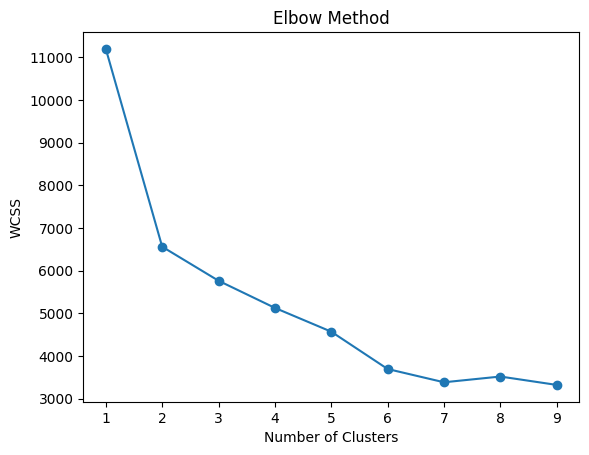

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

FIND OPTIMAL EPS (K-DISTANCE GRAPH) FOR THE DBSCAN

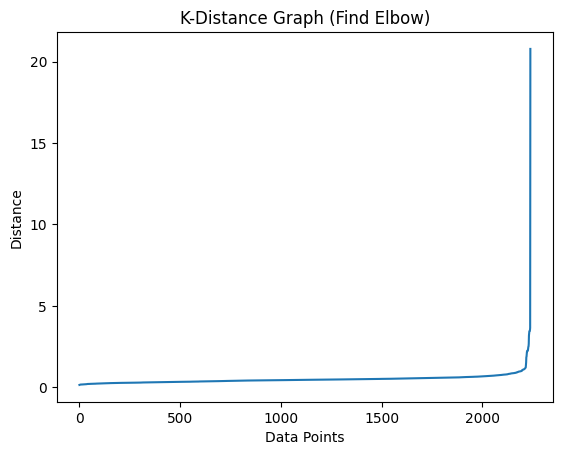

In [21]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:,4])
plt.figure()
plt.plot(distances)
plt.title("K-Distance Graph (Find Elbow)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

K-MEANS ALGORITHM

In [22]:
# kmeans algorithm
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

Text(0.5, 1.0, 'Customer Segmentation')

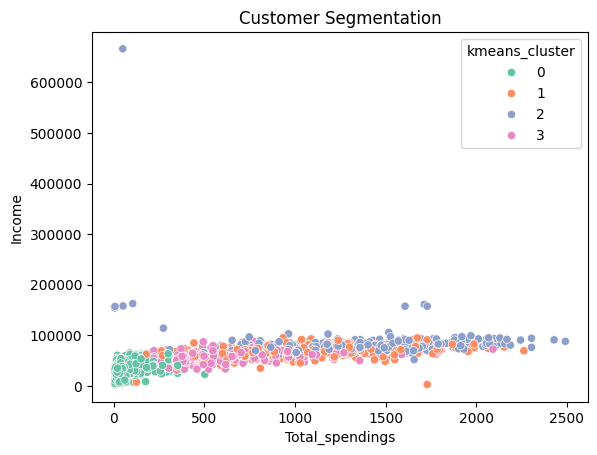

In [23]:
sns.scatterplot(x=df['Total_spendings'], y=df['Income'], hue=df['kmeans_cluster'], palette='Set2')
plt.title('Customer Segmentation')

DBSCAN ALGORITHM

In [24]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5,min_samples=5)
clusters = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = clusters

CHECKING THE CLUSTERS

In [25]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0     1469
-1      510
 2      146
 1       17
 3       15
 7       12
 6       12
 11       8
 4        7
 10       7
 12       7
 14       5
 8        5
 5        5
 13       5
 9        5
 15       4
 16       1
Name: count, dtype: int64

VISUALIZATION AFTER DBSCAN

Text(0.5, 1.0, 'DBSCAN Customer Segmentation')

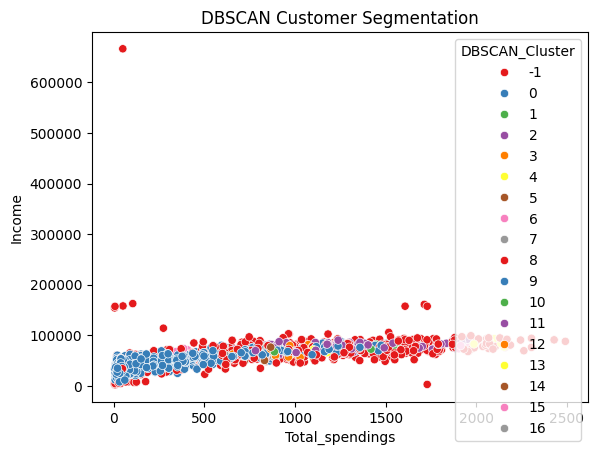

In [26]:
sns.scatterplot(x=df['Total_spendings'], y=df['Income'], hue=df['DBSCAN_Cluster'], palette='Set1')
plt.title('DBSCAN Customer Segmentation')

CONVERTING DBSCAN INTO CUSTOMER SEGMENTS

In [27]:
cluster_summary = df.groupby('DBSCAN_Cluster').mean(numeric_only=True)
cluster_count = df['DBSCAN_Cluster'].value_counts()
print(cluster_summary)
print(cluster_count)

                         ID   Year_Birth        Income   Kidhome  Teenhome  \
DBSCAN_Cluster                                                               
-1              5508.358824  1967.943137  67835.411765  0.190196  0.474510   
 0              5623.166099  1969.521443  43003.445882  0.603812  0.559564   
 1              6569.411765  1967.411765  79370.764706  0.000000  0.058824   
 2              5166.780822  1966.794521  76580.904110  0.006849  0.075342   
 3              4344.200000  1965.533333  60239.800000  0.133333  0.933333   
 4              6303.285714  1963.428571  83927.857143  0.000000  0.000000   
 5              6582.400000  1956.200000  51645.800000  0.600000  1.000000   
 6              6082.416667  1972.416667  78526.083333  0.000000  0.000000   
 7              5994.000000  1964.666667  59634.083333  0.083333  0.916667   
 8              7792.800000  1969.200000  59406.600000  0.200000  0.800000   
 9              6973.800000  1971.000000  74448.600000  0.000000

MAP CLUSTERS -> SEGMENTS

In [28]:
def assign_segment(row):
    if row['Income'] > 60000 and row['Total_spendings'] > 60:
        return 'Premium Customers'
    elif row['Income'] > 60000 and row['Total_spendings'] <= 60:
        return 'Potential Customers'
    elif row['Income'] <= 60000 and row['Total_spendings'] > 60:
        return 'Impulsive Buyers'
    elif row['Income'] <= 60000 and row['Total_spendings'] <= 60:
        return 'Budget Customers'
    else:
        return 'Others'

df['Customer_Segment'] = df.apply(assign_segment, axis=1)

HANDLE OUTLIERS

In [29]:
df.loc[df['DBSCAN_Cluster'] == -1, 'Customer_Segment'] = 'Outliers'

VISUALIZATION UPDATED

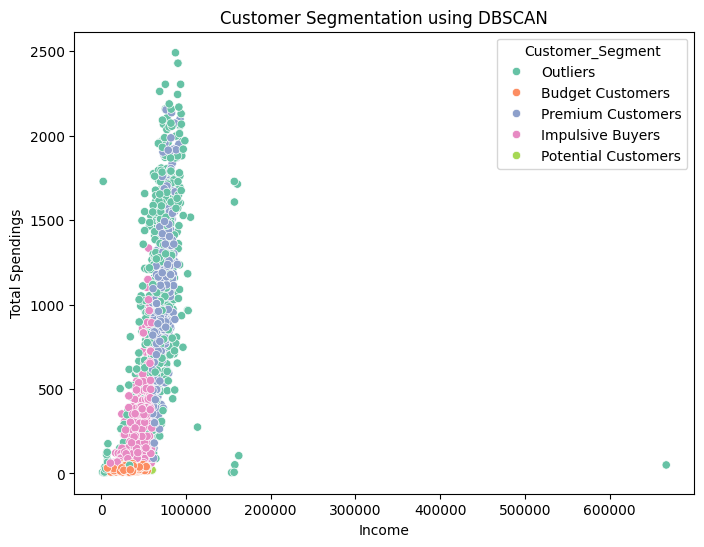

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Income'], y=df['Total_spendings'], hue=df['Customer_Segment'], palette='Set2')
plt.title('Customer Segmentation using DBSCAN')
plt.xlabel('Income')
plt.ylabel('Total Spendings')
plt.show()

COMPARISON OF BOTH MODELS : KMEANS AND DBSCAN <br>

K-Means and DBSCAN are both popular clustering algorithms used for customer segmentation, but they work in very different ways. <br>

K-Means divides the data into a fixed number of clusters by grouping similar data points around central points called centroids. It is simple, fast, and works well when the data is evenly distributed. However, you need to decide the number of clusters beforehand, and it doesn’t handle outliers very well.

DBSCAN, on the other hand, groups data based on density. Instead of fixing the number of clusters in advance, it automatically identifies clusters based on how closely packed the data points are. One of its biggest advantages is that it can also detect outliers. However, it requires careful tuning of parameters like eps and min_samples, and if not tuned properly, it can create too many small clusters.

In this project, K-Means gave clear and easy-to-understand customer groups, which made it more useful from a business point of view. DBSCAN, however, identified 16 clusters along with some outliers. While this helped capture more detailed patterns in the data, the results were harder to interpret and needed additional grouping to turn them into meaningful customer segments.

**CONCLUSION**

In this project, a Customer Intelligence System was developed using classification and clustering techniques to understand customer behavior. <br>
XGBoost performed slightly better than Random Forest in terms of accuracy, F1 score, and training time, making it a strong choice for prediction.
For clustering, both K-Means and DBSCAN were used. While K-Means provided simple and clear segments, DBSCAN proved to be more powerful as it can automatically detect clusters, capture complex patterns, and identify outliers.
Overall, DBSCAN offered deeper insights into customer behavior, making it a more flexible approach, while K-Means remained useful for basic segmentation. Combining these methods helped build a more effective system.

**Business Impact:**
This segmentation can help in targeted marketing, customer retention, and improving overall sales strategy.